## 📝 **Instrucciones**

### Campaña de Marketing Bancario
**Comprensión empresarial**

Los depósitos a largo plazo permiten a los bancos retener dinero durante un período de tiempo específico, lo que permite al banco utilizar ese dinero para mejorar sus inversiones. Las campañas de marketing de este producto se basan en llamadas telefónicas. Si un usuario no se encuentra disponible en un momento dado, entonces se le volverá a llamar de nuevo en otro momento.

**Descripción del problema**

El banco portugués está teniendo una disminución en sus ingresos, por lo que quieren poder identificar a los clientes existentes que tienen una mayor probabilidad de contratar un depósito a largo plazo. Esto permitirá que el banco centre sus esfuerzos de marketing en esos clientes y evitará perder dinero y tiempo en clientes que probablemente no se suscribirán.

Para abordar este problema crearemos un algoritmo de clasificación que ayude a predecir si un cliente contratará o no un depósito a largo plazo.


**Variables**

| Variable        | Descripción                                                                 | Tipo        |
|-----------------|-----------------------------------------------------------------------------|-------------|
| age             | Edad del cliente                                                            | Numérico    |
| job             | Tipo de trabajo                                                             | Categórico  |
| marital         | Estado civil                                                                | Categórico  |
| education       | Nivel de educación                                                          | Categórico  |
| default         | ¿Tiene crédito actualmente?                                                 | Categórico  |
| housing         | ¿Tiene un préstamo de vivienda?                                             | Categórico  |
| loan            | ¿Tiene un préstamo personal?                                                | Categórico  |
| contact         | Tipo de comunicación de contacto                                            | Categórico  |
| month           | Último mes en el que se le ha contactado                                    | Categórico  |
| day_of_week     | Último día en el que se le ha contactado                                    | Categórico  |
| duration        | Duración del contacto previo en segundos                                    | Numérico    |
| campaign        | Número de contactos realizados durante esta campaña al cliente              | Numérico    |
| pdays           | Número de días desde la última campaña hasta que fue contactado             | Numérico    |
| previous        | Número de contactos realizados durante la campaña anterior al cliente       | Numérico    |
| poutcome        | Resultado de la campaña de marketing anterior                               | Categórico  |
| emp.var.rate    | Tasa de variación del empleo (indicador trimestral)                         | Numérico    |
| cons.price.idx  | Índice de precios al consumidor (indicador mensual)                         | Numérico    |
| cons.conf.idx   | Índice de confianza del consumidor (indicador mensual)                      | Numérico    |
| euribor3m       | Tasa EURIBOR a 3 meses (indicador diario)                                   | Numérico    |
| nr.employed     | Número de empleados (indicador trimestral)                                  | Numérico    |
| y               | TARGET: El cliente contrata un depósito a largo plazo o no                  | Categórico  |


In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
import math

In [2]:
df = pd.read_csv('../data/raw/bank-marketing-campaign-data.csv', delimiter= ';')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  str    
 2   marital         41188 non-null  str    
 3   education       41188 non-null  str    
 4   default         41188 non-null  str    
 5   housing         41188 non-null  str    
 6   loan            41188 non-null  str    
 7   contact         41188 non-null  str    
 8   month           41188 non-null  str    
 9   day_of_week     41188 non-null  str    
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  str    
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null  float64
 1

In [3]:
#Estadistica descriptiva
df.describe(include='all')

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
count,41188.00000,41188,41188,41188,41188,41188,41188,41188,41188,41188,...,41188.000000,41188.000000,41188.000000,41188,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188
unique,NaN,12,4,8,3,3,3,2,10,5,...,NaN,NaN,NaN,3,NaN,NaN,NaN,NaN,NaN,2
top,NaN,admin.,married,university.degree,no,yes,no,cellular,may,thu,...,NaN,NaN,NaN,nonexistent,NaN,NaN,NaN,NaN,NaN,no
freq,NaN,10422,24928,12168,32588,21576,33950,26144,13769,8623,...,NaN,NaN,NaN,35563,NaN,NaN,NaN,NaN,NaN,36548
mean,40.02406,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2.567593,962.475454,0.172963,NaN,0.081886,93.575664,-40.502600,3.621291,5167.035911,NaN
std,10.42125,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2.770014,186.910907,0.494901,NaN,1.570960,0.578840,4.628198,1.734447,72.251528,NaN
min,17.00000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.000000,0.000000,0.000000,NaN,-3.400000,92.201000,-50.800000,0.634000,4963.600000,NaN
25%,32.00000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.000000,999.000000,0.000000,NaN,-1.800000,93.075000,-42.700000,1.344000,5099.100000,NaN
50%,38.00000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2.000000,999.000000,0.000000,NaN,1.100000,93.749000,-41.800000,4.857000,5191.000000,NaN
75%,47.00000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,3.000000,999.000000,0.000000,NaN,1.400000,93.994000,-36.400000,4.961000,5228.100000,NaN


## Conceptualmente: ¿Qué variables tiene sentido analizar y cuales sobran?

Primero vemos la relación que tiene la variable objetivo (Y) respecto variables numéricas y categóricas

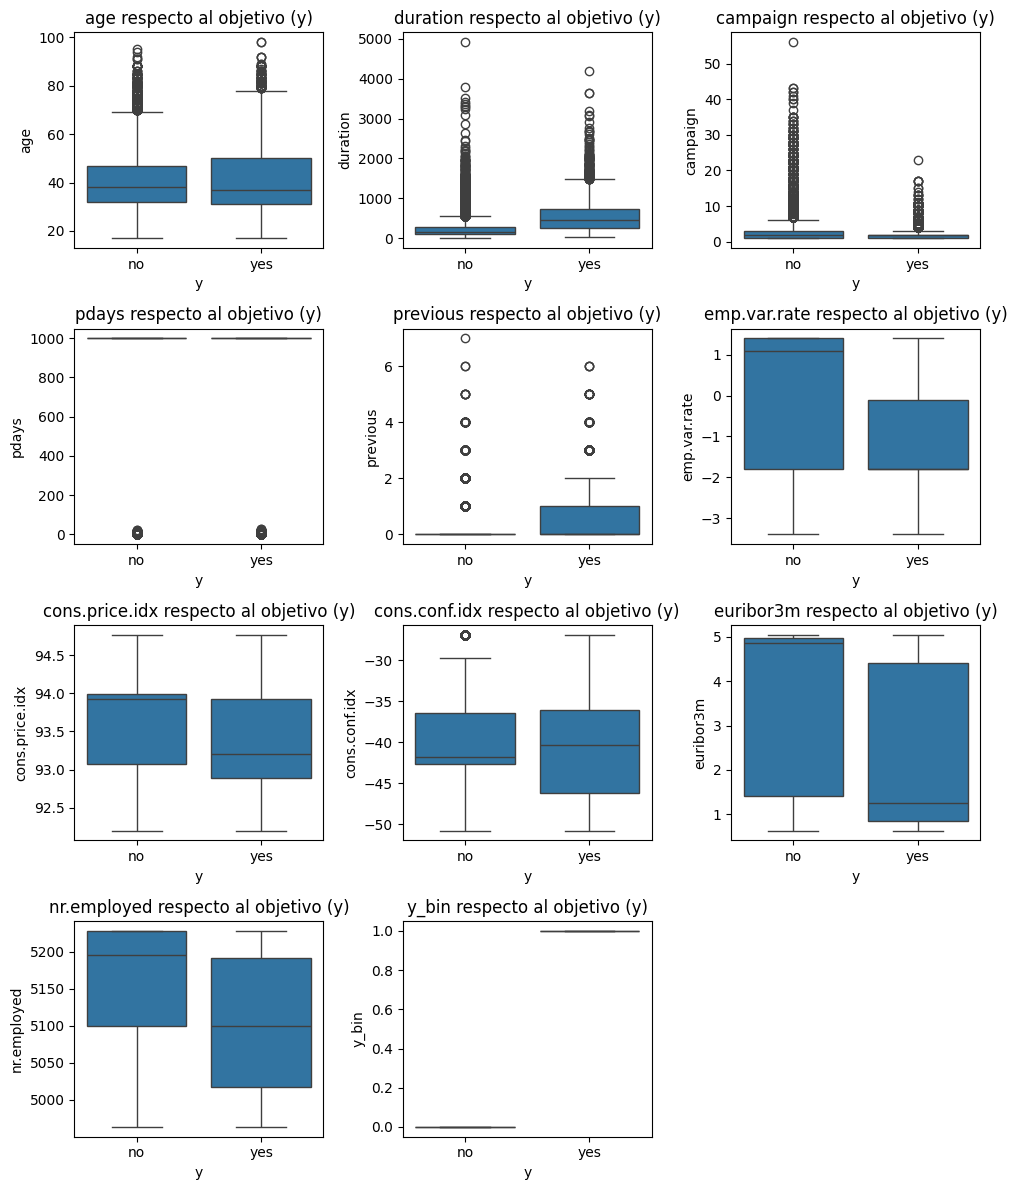

In [22]:
#layout de boxplots para variables numericas respecto a la variable y
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
num_cols = [col for col in num_cols if col != 'y']
n_cols = 3 
n_rows = math.ceil(len(num_cols) / n_cols)
plt.figure(figsize=(10, 3 * n_rows))

for i, col in enumerate(num_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.boxplot(x='y', y=col, data=df)
    plt.title(f'{col} respecto al objetivo (y)')

plt.tight_layout()
plt.show()

3 Variables con diferencia apreciable entre Sí y No:

    1. Euribor3m
    2. Campaign
    3. Previous

¿Qué hay de las variables categóricas?

C:\Users\bcastro\AppData\Local\Temp\ipykernel_28256\4040126906.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=45, ha='right')
C:\Users\bcastro\AppData\Local\Temp\ipykernel_28256\4040126906.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=45, ha='right')
C:\Users\bcastro\AppData\Local\Temp\ipykernel_28256\4040126906.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=45, ha='right')
C:\Users\bcastro\AppData\Local\Temp\ipykernel_28256\4040126906.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks()

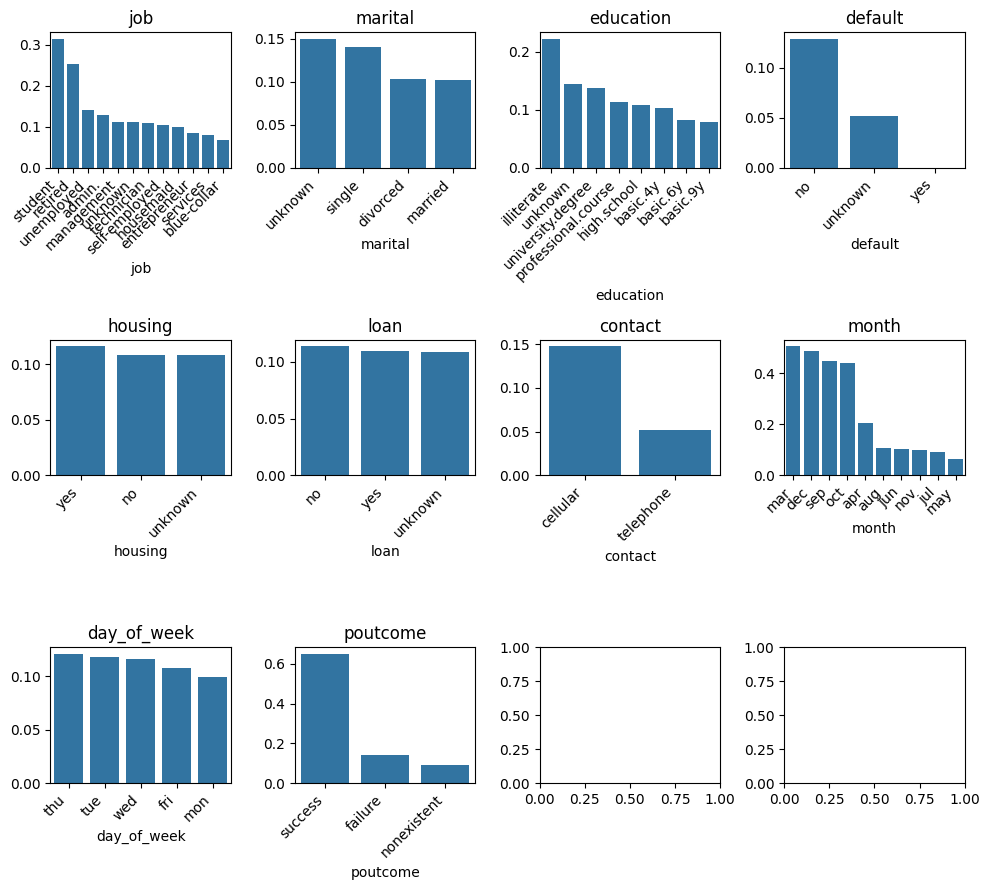

In [26]:
#factorizamos variable objetivo (y)
df['y_bin'] = df['y'].map({'yes': 1, 'no': 0})

cat_cols = df.select_dtypes(include='str').columns
cat_cols = [col for col in cat_cols if col != 'y']
n_cols = 4
n_rows = math.ceil(len(cat_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(10, 3 * n_rows))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    conv_rate = df.groupby(col)['y_bin'].mean().sort_values(ascending=False)
    sns.barplot(
        x=conv_rate.index,
        y=conv_rate.values,
        ax=axes[i]
    )
    
    axes[i].set_title(col)
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

Mantengo variable "poutcome" por ser la que tiene información más valiosa al estar relacionada con el objetivo y tener muy buena respuesta entre categorías

Ahora seguimos con la conversión de variables categóricas

In [27]:
df_encoded = pd.get_dummies(df, drop_first=True)
df_encoded.head()#

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,...,month_nov,month_oct,month_sep,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_nonexistent,poutcome_success,y_yes
0,56,261,1,999,0,1.1,93.994,-36.4,4.857,5191.0,...,False,False,False,True,False,False,False,True,False,False
1,57,149,1,999,0,1.1,93.994,-36.4,4.857,5191.0,...,False,False,False,True,False,False,False,True,False,False
2,37,226,1,999,0,1.1,93.994,-36.4,4.857,5191.0,...,False,False,False,True,False,False,False,True,False,False
3,40,151,1,999,0,1.1,93.994,-36.4,4.857,5191.0,...,False,False,False,True,False,False,False,True,False,False
4,56,307,1,999,0,1.1,93.994,-36.4,4.857,5191.0,...,False,False,False,True,False,False,False,True,False,False


In [28]:
#limpiamos variables que no se usarán para el modelo
cols_to_drop = [
    'duration',        
    'pdays',           
    'emp.var.rate',   
    'nr.employed',   
    'default_unknown',
    'default_yes',
    'y_bin'
]
df_model = df_encoded.drop(columns=cols_to_drop)
df_model.head()

,age,campaign,previous,cons.price.idx,cons.conf.idx,euribor3m,job_blue-collar,job_entrepreneur,job_housemaid,job_management,...,month_nov,month_oct,month_sep,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_nonexistent,poutcome_success,y_yes
0,56,1,0,93.994,-36.4,4.857,False,False,True,False,...,False,False,False,True,False,False,False,True,False,False
1,57,1,0,93.994,-36.4,4.857,False,False,False,False,...,False,False,False,True,False,False,False,True,False,False
2,37,1,0,93.994,-36.4,4.857,False,False,False,False,...,False,False,False,True,False,False,False,True,False,False
3,40,1,0,93.994,-36.4,4.857,False,False,False,False,...,False,False,False,True,False,False,False,True,False,False
4,56,1,0,93.994,-36.4,4.857,False,False,False,False,...,False,False,False,True,False,False,False,True,False,False


## Pasamos al modelo

In [29]:
#Separamos en test y train 80 - 20
X = df_model.drop('y_yes', axis=1)
y = df_model['y_yes']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [30]:
X = df_model.drop(columns=['y_yes'])
y = df_model['y_yes']
model = LogisticRegression(max_iter=1000, class_weight='balanced')
model.fit(X_train, y_train)

c:\Users\bcastro\Documents\Balam Castro\github\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

In [31]:
predictions = model.predict(X_test)
predictions

array([False, False, False, ..., False, False, False], shape=(8238,))

In [32]:
from sklearn.metrics import classification_report
print(classification_report(y_test,predictions))

              precision    recall  f1-score   support

       False       0.95      0.84      0.89      7303
        True       0.33      0.63      0.43       935

    accuracy                           0.81      8238
   macro avg       0.64      0.73      0.66      8238
weighted avg       0.88      0.81      0.84      8238



**Accuracy: 0.81 (81%)**
El modelo acierta en el 81% de los casos

**Recall: 0.63 (63%)**
El modelo detecta el 63% de los clientes que sí contratarán

**Precision: 0.33 (33%)**
El 33% de los clientes llamados no contratarán. 33% de falsos positivos o llamadas innecesarias.